## Study Design & Problem Formulation

This project develops a multi-horizon forecasting framework for emergency department demand to support staffing, patient flow, and resource allocation decisions.

The forecasting problem is separated into three planning horizons: short-term forecasts for the next 1 to 72 hours, medium-term forecasts for weekly or monthly planning, and long-term forecasts for seasonal or strategic capacity decisions.

The primary target is patient arrival volume. Operational resource pressure is evaluated with available signals such as admissions and wait times, giving the analysis a view of both expected demand and the strain associated with that demand.


## Imports and Setup

In [2]:
from pathlib import Path
import importlib.util
import os
import subprocess
import sys
import warnings

import pandas as pd

*Install Modeling Libraries*

In [3]:
# Install the plotting, statistical, and modeling libraries required by the remaining workflow.
required_modeling_packages = {
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "statsmodels": "statsmodels",
    "lightgbm": "lightgbm",
    "tensorflow": "tensorflow",
}

missing_packages = [
    package_name
    for module_name, package_name in required_modeling_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print(f"Installing missing packages: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing_packages])
else:
    print("All modeling libraries are already installed.")

Installing missing packages: ['matplotlib', 'seaborn', 'scikit-learn']


*Extended Modeling Imports*

In [4]:
# Import analysis, statistical testing, and modeling tools used below.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import InterpolationWarning

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.models import Sequential

warnings.filterwarnings("ignore", category=InterpolationWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

## Data Source and Reproducibility

This analysis uses the [Hospital Emergency Room dataset](https://www.kaggle.com/datasets/xavierberge/hospital-emergency-dataset) from Kaggle as the raw data source. The workflow preserves reproducibility by retrieving the dataset through the Kaggle API and retaining the extracted files in the project's raw-data directory.

A configured Kaggle CLI and valid API token are required to reproduce the download step. Using the source dataset directly ensures that the data preparation and forecasting workflow can be recreated from the raw files.


In [5]:
# Save raw data in the notebook data folder when running from the project root.
data_dir = Path("Notebook/data/raw") if Path("Notebook").exists() else Path("data/raw")
data_dir.mkdir(parents=True, exist_ok=True)

# Download and unzip the Kaggle dataset so the rest of the notebook can run from raw files.
try:
    subprocess.run(
        [
            "kaggle",
            "datasets",
            "download",
            "-d",
            "xavierberge/hospital-emergency-dataset",
            "-p",
            str(data_dir),
            "--unzip",
        ],
        check=True,
    )
    print(f"Downloaded dataset to {data_dir}")
except FileNotFoundError:
    print("Kaggle CLI not found. Install it with `pip install kaggle` and configure ~/.kaggle/kaggle.json.")
    sys.exit(1)
except subprocess.CalledProcessError as exc:
    print(f"Kaggle download failed with exit code {exc.returncode}.")
    sys.exit(exc.returncode)

Downloaded dataset to data\raw


### Raw Data Inspection

In [6]:
# Locate the raw ER file whether the notebook is run from the project root or Notebook/.
raw_path_candidates = [
    Path("Notebook/data/raw/Hospital ER_Data.csv"),
    Path("data/raw/Hospital ER_Data.csv"),
]
raw_path = next((path for path in raw_path_candidates if path.exists()), None)

if raw_path is None:
    searched_paths = "\n".join(str(path) for path in raw_path_candidates)
    raise FileNotFoundError(f"Expected raw CSV was not found. Searched:\n{searched_paths}")

# Read-only preview of the downloaded patient-level ER records.
raw_er = pd.read_csv(raw_path)

print(f"Raw data path: {raw_path}")
print(f"Raw data shape: {raw_er.shape}")
print("\nRaw data columns:")
print(raw_er.columns.tolist())
print("\nMissing values by column:")
print(raw_er.isna().sum())

Raw data path: data\raw\Hospital ER_Data.csv
Raw data shape: (9216, 12)

Raw data columns:
['Patient Id', 'Patient Admission Date', 'Patient First Inital', 'Patient Last Name', 'Patient Gender', 'Patient Age', 'Patient Race', 'Department Referral', 'Patient Admission Flag', 'Patient Satisfaction Score', 'Patient Waittime', 'Patients CM']

Missing values by column:
Patient Id                       0
Patient Admission Date           0
Patient First Inital             0
Patient Last Name                0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral           5400
Patient Admission Flag           0
Patient Satisfaction Score    6699
Patient Waittime                 0
Patients CM                      0
dtype: int64


*Raw Data Preview*

In [7]:
print("\nRaw data preview:")
raw_er.head()


Raw data preview:


,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,0
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,0
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,0
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,0
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,M,5,African American,Orthopedics,False,NaN,10,0


### Short-Term Forecasting: 1 to 72 Hours

The short-term forecasting task estimates emergency department demand over the next hour through the next 72 hours to support immediate staffing, room availability, and patient-flow readiness.

The primary objective is hourly ER arrival-volume forecasting. Operational pressure is assessed alongside volume through admission and wait-time patterns, which indicate whether a future hour may require additional beds, staffing attention, or patient-flow support.

An hourly dataset is used because ER demand can shift quickly within the same day. This structure supports modeling of recent arrival patterns, daily cycles, weekend effects, and short-window changes in operational pressure.


## Data Ingestion & Integration

The raw hospital ER file contains one record per patient encounter. The key timestamp for time-series processing is `Patient Admission Date`, which defines the arrival time for each encounter. Patient-level encounters were aggregated into hourly windows and saved as `hourly_patient_volume.csv`.

The resulting hourly dataset contains one row per hour of ER activity. `DateTime_Hour` provides the chronological time index, `Patient_Count` is the hourly arrival-volume target, `Hour` captures within-day patterns, `Day_Of_Week` captures weekly cycles, `Is_Weekend` identifies weekend behavior, and `Month` adds seasonal context. `Avg_Waittime` summarizes operational pressure, while `Admission_Count` captures admission burden for resource planning.

This structure provides the time index, target variable, and operational indicators required for short-term forecasting.


*Short-Term Forecast Dataset*


In [8]:
# Reuse the raw path from the inspection step when available; otherwise locate it directly.
if "raw_path" not in globals() or raw_path is None or not Path(raw_path).exists():
    raw_path_candidates = [
        Path("Notebook/data/raw/Hospital ER_Data.csv"),
        Path("data/raw/Hospital ER_Data.csv"),
    ]
    raw_path = next((path for path in raw_path_candidates if path.exists()), None)

    if raw_path is None:
        searched_paths = "\n".join(str(path) for path in raw_path_candidates)
        raise FileNotFoundError(f"Expected raw CSV was not found. Searched:\n{searched_paths}")

raw_path = Path(raw_path)
data_dir = raw_path.parent.parent
hourly_path = data_dir / "hourly_patient_volume.csv"

# Load the raw visit-level ER records when this section is run independently.
raw_er = pd.read_csv(raw_path)

# Parse the admission timestamp used to order visits over time.
raw_er["Patient_Admission_Timestamp"] = pd.to_datetime(
    raw_er["Patient Admission Date"],
    format="%d-%m-%Y %H:%M",
    errors="coerce",
)

# Stop early if any timestamp cannot be parsed, because forecasting requires chronological integrity.
missing_timestamps = raw_er["Patient_Admission_Timestamp"].isna().sum()
if missing_timestamps:
    raise ValueError(f"Unable to parse {missing_timestamps} admission timestamps.")

# Convert each visit timestamp into an hourly bucket for short-term forecasting.
raw_er["DateTime_Hour"] = raw_er["Patient_Admission_Timestamp"].dt.floor("h")

# Aggregate patient visits into one row per hour.
hourly_forecast = (
    raw_er.groupby("DateTime_Hour")
    .agg(
        Patient_Count=("Patient Id", "count"),
        Avg_Waittime=("Patient Waittime", "mean"),
        Admission_Count=("Patient Admission Flag", "sum"),
    )
    .reset_index()
)

# Add calendar features that help models learn daily, weekly, and seasonal demand patterns.
hourly_forecast["Hour"] = hourly_forecast["DateTime_Hour"].dt.hour
hourly_forecast["Day_Of_Week"] = hourly_forecast["DateTime_Hour"].dt.day_name()
hourly_forecast["Is_Weekend"] = hourly_forecast["DateTime_Hour"].dt.dayofweek >= 5
hourly_forecast["Month"] = hourly_forecast["DateTime_Hour"].dt.to_period("M").astype(str)

# Keep a clear column order and round wait time for a cleaner saved dataset.
hourly_forecast = hourly_forecast[
    [
        "DateTime_Hour",
        "Patient_Count",
        "Hour",
        "Day_Of_Week",
        "Is_Weekend",
        "Month",
        "Avg_Waittime",
        "Admission_Count",
    ]
]
hourly_forecast["Avg_Waittime"] = hourly_forecast["Avg_Waittime"].round(2)
hourly_forecast["DateTime_Hour"] = hourly_forecast["DateTime_Hour"].dt.strftime("%Y-%m-%d %H:%M")

# Save the reproducible short-term forecasting dataset generated from raw data.
hourly_forecast.to_csv(hourly_path, index=False)
print(f"Saved hourly forecasting dataset to {hourly_path}")


Saved hourly forecasting dataset to data\hourly_patient_volume.csv


### Dataset Validation Check

In [9]:
# Inspect the generated hourly forecasting dataset.
print(f"\nHourly forecasting data shape: {hourly_forecast.shape}")
print("Hourly forecasting columns:")
print(hourly_forecast.columns.tolist())

duplicate_hours = hourly_forecast["DateTime_Hour"].duplicated().sum()
print(f"\nDuplicate hourly timestamps: {duplicate_hours}")

hourly_timestamps = pd.to_datetime(hourly_forecast["DateTime_Hour"])
is_chronological = hourly_timestamps.is_monotonic_increasing
print(f"Chronologically sorted: {is_chronological}")


Hourly forecasting data shape: (6757, 8)
Hourly forecasting columns:
['DateTime_Hour', 'Patient_Count', 'Hour', 'Day_Of_Week', 'Is_Weekend', 'Month', 'Avg_Waittime', 'Admission_Count']

Duplicate hourly timestamps: 0
Chronologically sorted: True


*Hourly Forecast Preview*

In [10]:
print("\nHourly Forecasting Data:")
hourly_forecast.head()


Hourly Forecasting Data:


,DateTime_Hour,Patient_Count,Hour,Day_Of_Week,Is_Weekend,Month,Avg_Waittime,Admission_Count
0,2023-04-01 01:00,2,1,Saturday,True,2023-04,37.5,2
1,2023-04-01 02:00,1,2,Saturday,True,2023-04,12.0,0
2,2023-04-01 04:00,1,4,Saturday,True,2023-04,21.0,0
3,2023-04-01 06:00,1,6,Saturday,True,2023-04,52.0,1
4,2023-04-01 07:00,1,7,Saturday,True,2023-04,50.0,1


## Data Cleaning & Quality Assurance

This section verifies that the source fields required for hourly aggregation are complete, valid, and chronologically reliable. The primary modeling dataset for the current workflow is the generated hourly forecasting table, so quality checks focus on timestamp integrity, duplicate records, missing modeling values, chronological order, and reasonable numeric ranges.

*Raw Data Quality Checks*


In [11]:
# Minimal source QA for fields used to build the hourly forecasting dataset.
required_raw_columns = [
    "Patient Id",
    "Patient Admission Date",
    "Patient Waittime",
    "Patient Admission Flag",
]
missing_required_columns = [column for column in required_raw_columns if column not in raw_er.columns]
if missing_required_columns:
    raise ValueError(f"Missing required raw columns: {missing_required_columns}")

qa_timestamps = pd.to_datetime(
    raw_er["Patient Admission Date"],
    format="%d-%m-%Y %H:%M",
    errors="coerce",
)
timestamp_parse_failures = qa_timestamps.isna().sum()
missing_patient_ids = raw_er["Patient Id"].isna().sum()
negative_wait_times = (raw_er["Patient Waittime"] < 0).sum()
duplicate_full_records = raw_er.duplicated().sum()
boolean_like_admission_flag = raw_er["Patient Admission Flag"].dropna().isin([True, False, 0, 1]).all()

source_qa_summary = pd.DataFrame(
    {
        "Check": [
            "Required columns missing",
            "Timestamp parse failures",
            "Missing patient IDs",
            "Negative wait times",
            "Duplicate full records",
            "Admission flag boolean-like",
        ],
        "Result": [
            len(missing_required_columns),
            timestamp_parse_failures,
            missing_patient_ids,
            negative_wait_times,
            duplicate_full_records,
            boolean_like_admission_flag,
        ],
    }
)

display(source_qa_summary)

if timestamp_parse_failures or missing_patient_ids or negative_wait_times or not boolean_like_admission_flag:
    raise ValueError("Raw source QA failed for one or more aggregation fields.")


,Check,Result
0,Required columns missing,0
1,Timestamp parse failures,0
2,Missing patient IDs,0
3,Negative wait times,0
4,Duplicate full records,0
5,Admission flag boolean-like,True


*Validate Hourly Forecast Dataset*

In [12]:
# Clean and validate the hourly forecasting dataset used for modeling.
hourly_forecast_clean = hourly_forecast.copy()
hourly_forecast_clean["DateTime_Hour"] = pd.to_datetime(hourly_forecast_clean["DateTime_Hour"])
hourly_forecast_clean = hourly_forecast_clean.sort_values("DateTime_Hour").reset_index(drop=True)

modeling_columns = [
    "DateTime_Hour",
    "Patient_Count",
    "Hour",
    "Day_Of_Week",
    "Is_Weekend",
    "Month",
    "Avg_Waittime",
    "Admission_Count",
]

missing_modeling_values = hourly_forecast_clean[modeling_columns].isna().sum()
duplicate_hourly_timestamps = hourly_forecast_clean["DateTime_Hour"].duplicated().sum()
chronologically_sorted = hourly_forecast_clean["DateTime_Hour"].is_monotonic_increasing
invalid_patient_counts = (hourly_forecast_clean["Patient_Count"] < 0).sum()
invalid_wait_times = (hourly_forecast_clean["Avg_Waittime"] < 0).sum()
invalid_admission_counts = (hourly_forecast_clean["Admission_Count"] < 0).sum()

hourly_qa_summary = pd.DataFrame(
    {
        "Check": [
            "Duplicate hourly timestamps",
            "Chronologically sorted",
            "Invalid patient counts",
            "Invalid average wait times",
            "Invalid admission counts",
            "Rows in clean hourly dataset",
        ],
        "Result": [
            duplicate_hourly_timestamps,
            chronologically_sorted,
            invalid_patient_counts,
            invalid_wait_times,
            invalid_admission_counts,
            len(hourly_forecast_clean),
        ],
    }
)

display(hourly_qa_summary)
print("\nMissing modeling values by column:")
display(missing_modeling_values.to_frame("Missing_Count"))
print("\nClean hourly numeric summary:")
display(hourly_forecast_clean[["Patient_Count", "Avg_Waittime", "Admission_Count"]].describe())

if duplicate_hourly_timestamps or not chronologically_sorted or missing_modeling_values.any():
    raise ValueError("Hourly forecasting QA failed for duplicate, ordering, or missing-value checks.")
if invalid_patient_counts or invalid_wait_times or invalid_admission_counts:
    raise ValueError("Hourly forecasting QA failed for numeric range checks.")



,Check,Result
0,Duplicate hourly timestamps,0
1,Chronologically sorted,True
2,Invalid patient counts,0
3,Invalid average wait times,0
4,Invalid admission counts,0
5,Rows in clean hourly dataset,6757



Missing modeling values by column:


,Missing_Count
DateTime_Hour,0
Patient_Count,0
Hour,0
Day_Of_Week,0
Is_Weekend,0
Month,0
Avg_Waittime,0
Admission_Count,0



Clean hourly numeric summary:


,Patient_Count,Avg_Waittime,Admission_Count
count,6757.000000,6757.000000,6757.000000
mean,1.363919,35.317438,0.682551
std,0.639406,13.543620,0.672789
min,1.000000,10.000000,0.000000
25%,1.000000,24.500000,0.000000
50%,1.000000,35.000000,1.000000
75%,2.000000,46.000000,1.000000
max,6.000000,60.000000,5.000000


*Create Continuous Hourly Timeline*

The observed hourly dataset only includes hours with at least one recorded ER arrival. This step creates a regular hourly time series by inserting zero-arrival hours between the first and last observed timestamp, which prepares the data for time-series decomposition, autocorrelation analysis, and forecasting.

In [13]:
# Create a continuous hourly time series for EDA and forecasting.
if "hourly_forecast_clean" not in globals():
    hourly_path_candidates = [
        Path("Notebook/data/hourly_patient_volume.csv"),
        Path("data/hourly_patient_volume.csv"),
    ]
    hourly_path = next((path for path in hourly_path_candidates if path.exists()), None)
    if hourly_path is None:
        searched_paths = "\n".join(str(path) for path in hourly_path_candidates)
        raise FileNotFoundError(f"Expected hourly CSV was not found. Searched:\n{searched_paths}")

    hourly_forecast_clean = pd.read_csv(hourly_path)
    hourly_forecast_clean["DateTime_Hour"] = pd.to_datetime(hourly_forecast_clean["DateTime_Hour"])
    hourly_forecast_clean = hourly_forecast_clean.sort_values("DateTime_Hour").reset_index(drop=True)

hourly_forecast_clean = hourly_forecast_clean.copy()
hourly_forecast_clean["DateTime_Hour"] = pd.to_datetime(hourly_forecast_clean["DateTime_Hour"])
hourly_forecast_clean = hourly_forecast_clean.sort_values("DateTime_Hour").reset_index(drop=True)

full_hourly_range = pd.date_range(
    hourly_forecast_clean["DateTime_Hour"].min(),
    hourly_forecast_clean["DateTime_Hour"].max(),
    freq="h",
)

hourly_forecast_regular = pd.DataFrame({"DateTime_Hour": full_hourly_range}).merge(
    hourly_forecast_clean,
    on="DateTime_Hour",
    how="left",
    indicator=True,
)
hourly_forecast_regular["Was_Observed_Hour"] = hourly_forecast_regular["_merge"].eq("both")
hourly_forecast_regular = hourly_forecast_regular.drop(columns="_merge")

# Inserted rows represent hours with no recorded arrivals.
hourly_forecast_regular["Patient_Count"] = hourly_forecast_regular["Patient_Count"].fillna(0).astype(int)
hourly_forecast_regular["Admission_Count"] = hourly_forecast_regular["Admission_Count"].fillna(0).astype(int)

# Calendar features are recalculated from the complete hourly index.
hourly_forecast_regular["Hour"] = hourly_forecast_regular["DateTime_Hour"].dt.hour
hourly_forecast_regular["Day_Of_Week"] = hourly_forecast_regular["DateTime_Hour"].dt.day_name()
hourly_forecast_regular["Is_Weekend"] = hourly_forecast_regular["DateTime_Hour"].dt.dayofweek >= 5
hourly_forecast_regular["Month"] = hourly_forecast_regular["DateTime_Hour"].dt.to_period("M").astype(str)

hourly_forecast_regular = hourly_forecast_regular[
    [
        "DateTime_Hour",
        "Patient_Count",
        "Hour",
        "Day_Of_Week",
        "Is_Weekend",
        "Month",
        "Avg_Waittime",
        "Admission_Count",
        "Was_Observed_Hour",
    ]
]

observed_rows = hourly_forecast_regular["Was_Observed_Hour"].sum()
inserted_zero_arrival_hours = (~hourly_forecast_regular["Was_Observed_Hour"]).sum()

# Validate the regularized hourly series.
if hourly_forecast_regular["DateTime_Hour"].isna().any():
    raise ValueError("Regularized hourly data contains missing timestamps.")
if hourly_forecast_regular["DateTime_Hour"].duplicated().any():
    raise ValueError("Regularized hourly data contains duplicate timestamps.")
if not hourly_forecast_regular["DateTime_Hour"].is_monotonic_increasing:
    raise ValueError("Regularized hourly data is not chronologically sorted.")
if len(hourly_forecast_regular) != len(full_hourly_range):
    raise ValueError("Regularized hourly row count does not match the full hourly range.")

inserted_rows = hourly_forecast_regular[~hourly_forecast_regular["Was_Observed_Hour"]]
if (inserted_rows["Patient_Count"] != 0).any() or (inserted_rows["Admission_Count"] != 0).any():
    raise ValueError("Inserted zero-arrival hours were not filled correctly.")

observed_comparison = hourly_forecast_clean[
    ["DateTime_Hour", "Patient_Count", "Admission_Count", "Avg_Waittime"]
].merge(
    hourly_forecast_regular.loc[
        hourly_forecast_regular["Was_Observed_Hour"],
        ["DateTime_Hour", "Patient_Count", "Admission_Count", "Avg_Waittime"],
    ],
    on="DateTime_Hour",
    suffixes=("_original", "_regular"),
)
original_rows_unchanged = (
    observed_comparison["Patient_Count_original"].equals(observed_comparison["Patient_Count_regular"])
    and observed_comparison["Admission_Count_original"].equals(observed_comparison["Admission_Count_regular"])
    and observed_comparison["Avg_Waittime_original"].equals(observed_comparison["Avg_Waittime_regular"])
)
if not original_rows_unchanged:
    raise ValueError("Observed hourly rows changed during regularization.")

regular_data_dir = Path("Notebook/data") if Path("Notebook/data").exists() else Path("data")
regular_hourly_path = regular_data_dir / "hourly_patient_volume_regular.csv"
hourly_forecast_regular.to_csv(regular_hourly_path, index=False)

regular_qa_summary = pd.DataFrame(
    {
        "Metric": [
            "Observed arrival-hour rows",
            "Full hourly rows",
            "Inserted zero-arrival hours",
            "Unique hourly timestamps",
            "Chronologically sorted",
            "Original observed rows unchanged",
            "Saved regularized path",
        ],
        "Value": [
            observed_rows,
            len(hourly_forecast_regular),
            inserted_zero_arrival_hours,
            hourly_forecast_regular["DateTime_Hour"].is_unique,
            hourly_forecast_regular["DateTime_Hour"].is_monotonic_increasing,
            original_rows_unchanged,
            str(regular_hourly_path),
        ],
    }
)

display(regular_qa_summary)

,Metric,Value
0,Observed arrival-hour rows,6757
1,Full hourly rows,13895
2,Inserted zero-arrival hours,7138
3,Unique hourly timestamps,True
4,Chronologically sorted,True
5,Original observed rows unchanged,True
6,Saved regularized path,data\hourly_patient_volume_regular.csv


In [14]:
hourly_forecast_regular.head()

,DateTime_Hour,Patient_Count,Hour,Day_Of_Week,Is_Weekend,Month,Avg_Waittime,Admission_Count,Was_Observed_Hour
0,2023-04-01 01:00:00,2,1,Saturday,True,2023-04,37.5,2,True
1,2023-04-01 02:00:00,1,2,Saturday,True,2023-04,12.0,0,True
2,2023-04-01 03:00:00,0,3,Saturday,True,2023-04,NaN,0,False
3,2023-04-01 04:00:00,1,4,Saturday,True,2023-04,21.0,0,True
4,2023-04-01 05:00:00,0,5,Saturday,True,2023-04,NaN,0,False


## Exploratory Time-Series Analysis

This section examines whether the regularized hourly arrival series is stable enough for forecasting, identifies daily and weekly demand structure, and measures how strongly current arrivals depend on prior hours.

*Load Regularized Hourly Series*

In [15]:
# Use the regularized hourly dataset created during data cleaning.
if "hourly_forecast_regular" in globals():
    analysis_df = hourly_forecast_regular.copy()
else:
    regular_path_candidates = [
        Path("Notebook/data/hourly_patient_volume_regular.csv"),
        Path("data/hourly_patient_volume_regular.csv"),
    ]
    regular_hourly_path = next((path for path in regular_path_candidates if path.exists()), None)
    if regular_hourly_path is None:
        searched_paths = "\n".join(str(path) for path in regular_path_candidates)
        raise FileNotFoundError(f"Expected regularized hourly CSV was not found. Searched:\n{searched_paths}")
    analysis_df = pd.read_csv(regular_hourly_path)

analysis_df["DateTime_Hour"] = pd.to_datetime(analysis_df["DateTime_Hour"])
analysis_df = analysis_df.sort_values("DateTime_Hour").reset_index(drop=True)
analysis_df = analysis_df.set_index("DateTime_Hour").asfreq("h")
analysis_df["Patient_Count"] = analysis_df["Patient_Count"].fillna(0).astype(int)
analysis_df["Admission_Count"] = analysis_df["Admission_Count"].fillna(0).astype(int)

eda_series = analysis_df["Patient_Count"].astype(float)
regular_series_summary = pd.DataFrame(
    {
        "Metric": [
            "Start timestamp",
            "End timestamp",
            "Hourly rows",
            "Missing patient counts",
            "Average hourly arrivals",
            "Median hourly arrivals",
            "Maximum hourly arrivals",
        ],
        "Value": [
            analysis_df.index.min(),
            analysis_df.index.max(),
            len(analysis_df),
            analysis_df["Patient_Count"].isna().sum(),
            round(analysis_df["Patient_Count"].mean(), 3),
            analysis_df["Patient_Count"].median(),
            analysis_df["Patient_Count"].max(),
        ],
    }
)

display(regular_series_summary)

,Metric,Value
0,Start timestamp,2023-04-01 01:00:00
1,End timestamp,2024-10-30 23:00:00
2,Hourly rows,13895
3,Missing patient counts,0
4,Average hourly arrivals,0.663
5,Median hourly arrivals,0.0
6,Maximum hourly arrivals,6


The regularized hourly series is the right foundation for time-series analysis because every hour between the first and last timestamp is represented. Zero-arrival hours are meaningful demand observations, not missing data, so they should remain in the target series.

*Visualize Hourly Patient Volume*

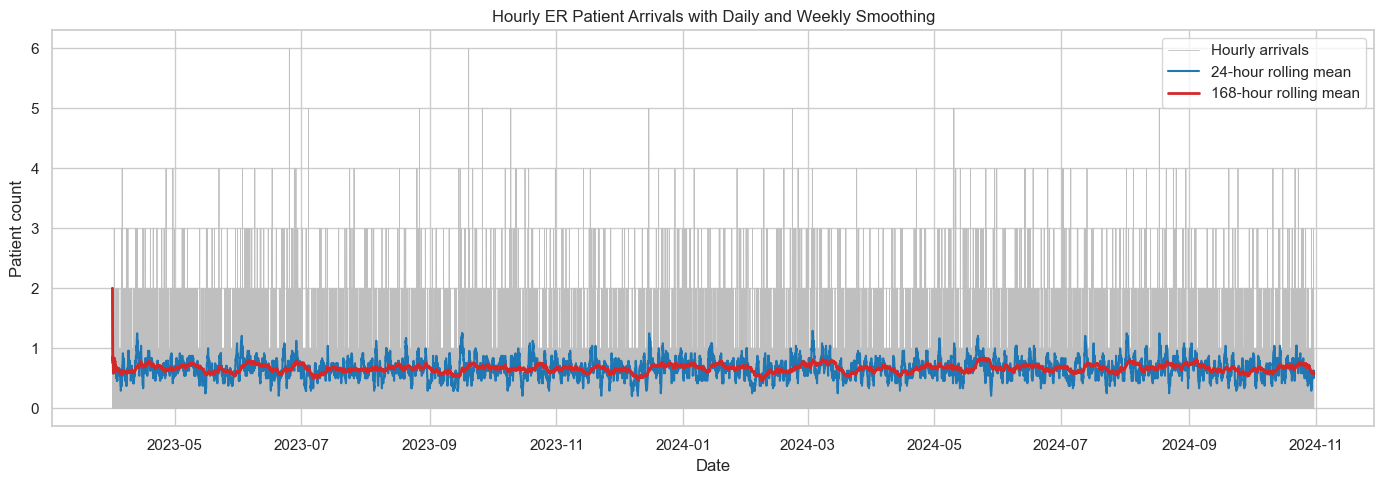

In [16]:
# Plot hourly arrivals with daily and weekly smoothing to reveal operational demand patterns.
volume_plot_df = analysis_df[["Patient_Count"]].copy()
volume_plot_df["Daily_Rolling_Mean"] = volume_plot_df["Patient_Count"].rolling(24, min_periods=1).mean()
volume_plot_df["Weekly_Rolling_Mean"] = volume_plot_df["Patient_Count"].rolling(168, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(volume_plot_df.index, volume_plot_df["Patient_Count"], color="0.75", linewidth=0.6, label="Hourly arrivals")
ax.plot(volume_plot_df.index, volume_plot_df["Daily_Rolling_Mean"], color="#1f77b4", linewidth=1.5, label="24-hour rolling mean")
ax.plot(volume_plot_df.index, volume_plot_df["Weekly_Rolling_Mean"], color="#d62728", linewidth=2.0, label="168-hour rolling mean")
ax.set_title("Hourly ER Patient Arrivals with Daily and Weekly Smoothing")
ax.set_xlabel("Date")
ax.set_ylabel("Patient count")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

The raw hourly line shows short-term volatility, while the 24-hour and 168-hour rolling means separate day-to-day noise from broader demand movement. If the weekly smoother changes slowly, the forecasting models should emphasize recent lags and recurring calendar structure rather than a strong long-term trend.

*Stationarity Tests*

In [17]:
# Test whether the hourly patient-arrival process behaves like a stationary time series.
stationarity_series = eda_series.dropna()
adf_result = adfuller(stationarity_series, autolag="AIC")
kpss_result = kpss(stationarity_series, regression="c", nlags="auto")

stationarity_summary = pd.DataFrame(
    {
        "Test": ["ADF", "KPSS"],
        "Null Hypothesis": ["Series has a unit root", "Series is level-stationary"],
        "Test Statistic": [adf_result[0], kpss_result[0]],
        "p-value": [adf_result[1], kpss_result[1]],
        "Used Lags": [adf_result[2], kpss_result[2]],
        "Decision at 0.05": [
            "Reject unit-root null" if adf_result[1] < 0.05 else "Fail to reject unit-root null",
            "Reject stationarity null" if kpss_result[1] < 0.05 else "Fail to reject stationarity null",
        ],
    }
)

display(stationarity_summary)

,Test,Null Hypothesis,Test Statistic,p-value,Used Lags,Decision at 0.05
0,ADF,Series has a unit root,-118.568209,0.0,0,Reject unit-root null
1,KPSS,Series is level-stationary,0.084340,0.1,7,Fail to reject stationarity null


ADF and KPSS test opposite null hypotheses, so reading them together is more reliable than using either test alone. ADF significance supports stationarity after accounting for autocorrelation; KPSS significance warns that deterministic structure or seasonality may still remain and should be modeled explicitly.

*STL Decomposition*

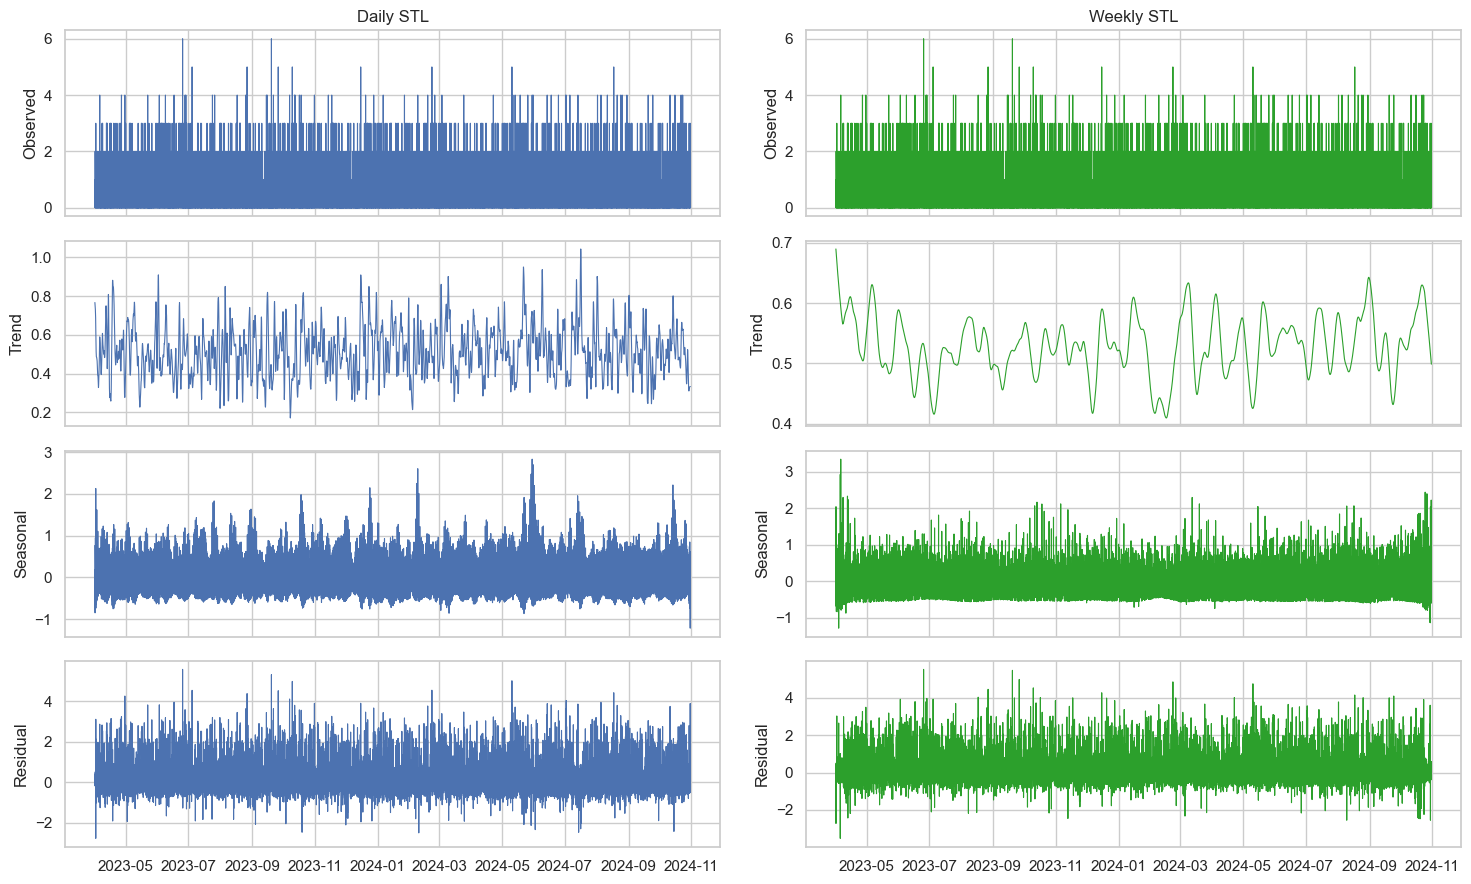

In [18]:
# Decompose the hourly series into trend, seasonal, and residual components.
stl_daily = STL(eda_series, period=24, robust=True).fit()
stl_weekly = STL(eda_series, period=168, robust=True).fit()

fig, axes = plt.subplots(4, 2, figsize=(15, 9), sharex=True)
components = [
    ("Observed", eda_series),
    ("Trend", stl_daily.trend),
    ("Seasonal", stl_daily.seasonal),
    ("Residual", stl_daily.resid),
]
for row, (label, values) in enumerate(components):
    axes[row, 0].plot(values.index, values, linewidth=0.8)
    axes[row, 0].set_ylabel(label)
    axes[row, 0].set_title("Daily STL" if row == 0 else "")

weekly_components = [
    ("Observed", eda_series),
    ("Trend", stl_weekly.trend),
    ("Seasonal", stl_weekly.seasonal),
    ("Residual", stl_weekly.resid),
]
for row, (label, values) in enumerate(weekly_components):
    axes[row, 1].plot(values.index, values, linewidth=0.8, color="#2ca02c")
    axes[row, 1].set_ylabel(label)
    axes[row, 1].set_title("Weekly STL" if row == 0 else "")

plt.tight_layout()
plt.show()

The daily decomposition isolates within-day arrival rhythms, while the weekly decomposition checks whether demand repeats across the same hour of the week. Residual spikes are important because they represent irregular arrival surges that simple calendar features may not fully explain.

*Autocorrelation Analysis*

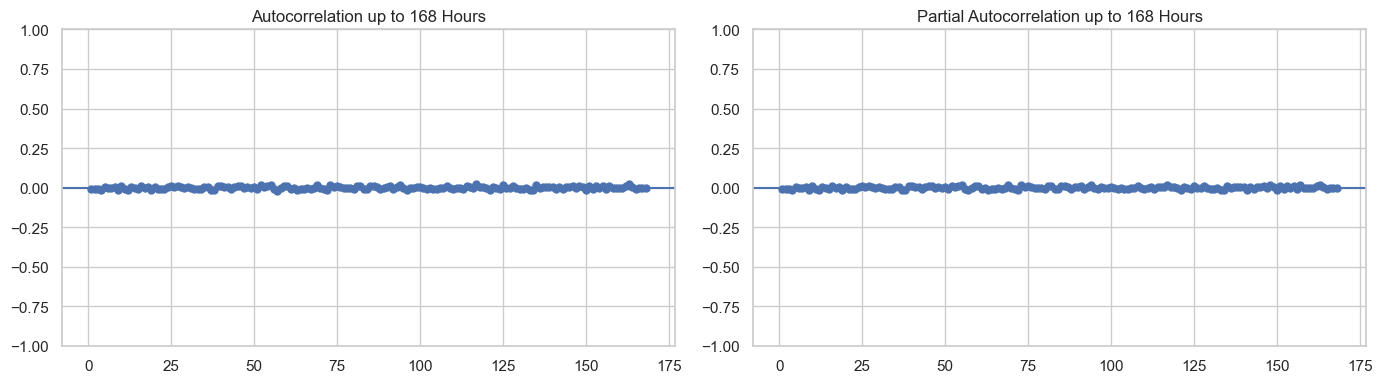

In [19]:
# Analyze temporal dependence through one full week of hourly lags.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(eda_series, lags=168, ax=axes[0], zero=False)
axes[0].set_title("Autocorrelation up to 168 Hours")
plot_pacf(eda_series, lags=168, ax=axes[1], zero=False, method="ywm")
axes[1].set_title("Partial Autocorrelation up to 168 Hours")
plt.tight_layout()
plt.show()

ACF peaks around 24-hour or 168-hour lags indicate repeated daily or weekly arrival patterns. PACF highlights direct lag relationships and helps justify the lag features used in the supervised forecasting dataset.

## Feature Engineering & Temporal Embedding

This section converts the regularized hourly target into supervised learning rows with lag history, rolling demand context, cyclical calendar encodings, and representative short-term forecast targets.

*Create Temporal Features and Forecast Targets*

In [20]:
# Build leakage-safe features from information available at the forecast origin.
modeling_df = analysis_df.reset_index().rename(columns={"DateTime_Hour": "Forecast_Origin"})
modeling_df["Patient_Count"] = modeling_df["Patient_Count"].astype(float)

lag_hours = [1, 2, 3, 6, 12, 24, 48, 72, 168]
rolling_windows = [3, 6, 12, 24, 72, 168]
target_horizons = {1: "Target_1h", 6: "Target_6h", 24: "Target_24h", 72: "Target_72h"}

for lag in lag_hours:
    modeling_df[f"Lag_{lag}h"] = modeling_df["Patient_Count"].shift(lag)

shifted_target = modeling_df["Patient_Count"].shift(1)
for window in rolling_windows:
    modeling_df[f"Rolling_Mean_{window}h"] = shifted_target.rolling(window).mean()
    modeling_df[f"Rolling_Std_{window}h"] = shifted_target.rolling(window).std()

modeling_df["Hour"] = modeling_df["Forecast_Origin"].dt.hour
modeling_df["Day_Of_Week_Num"] = modeling_df["Forecast_Origin"].dt.dayofweek
modeling_df["Month_Num"] = modeling_df["Forecast_Origin"].dt.month
modeling_df["Is_Weekend"] = modeling_df["Day_Of_Week_Num"].isin([5, 6]).astype(int)
modeling_df["Is_Flu_Season"] = modeling_df["Month_Num"].isin([10, 11, 12, 1, 2, 3]).astype(int)

modeling_df["Hour_Sin"] = np.sin(2 * np.pi * modeling_df["Hour"] / 24)
modeling_df["Hour_Cos"] = np.cos(2 * np.pi * modeling_df["Hour"] / 24)
modeling_df["Day_Of_Week_Sin"] = np.sin(2 * np.pi * modeling_df["Day_Of_Week_Num"] / 7)
modeling_df["Day_Of_Week_Cos"] = np.cos(2 * np.pi * modeling_df["Day_Of_Week_Num"] / 7)
modeling_df["Month_Sin"] = np.sin(2 * np.pi * modeling_df["Month_Num"] / 12)
modeling_df["Month_Cos"] = np.cos(2 * np.pi * modeling_df["Month_Num"] / 12)

for horizon, target_column in target_horizons.items():
    modeling_df[target_column] = modeling_df["Patient_Count"].shift(-horizon)

feature_columns = (
    [f"Lag_{lag}h" for lag in lag_hours]
    + [f"Rolling_Mean_{window}h" for window in rolling_windows]
    + [f"Rolling_Std_{window}h" for window in rolling_windows]
    + [
        "Hour_Sin",
        "Hour_Cos",
        "Day_Of_Week_Sin",
        "Day_Of_Week_Cos",
        "Month_Sin",
        "Month_Cos",
        "Is_Weekend",
        "Is_Flu_Season",
    ]
)
target_columns = list(target_horizons.values())
leakage_columns = {"Avg_Waittime", "Admission_Count", "Was_Observed_Hour"}
if leakage_columns.intersection(feature_columns):
    raise ValueError("Leakage-prone operational outcome columns were included as predictors.")

feature_df = modeling_df.dropna(subset=feature_columns + target_columns).reset_index(drop=True)

feature_summary = pd.DataFrame(
    {
        "Metric": [
            "Feature rows",
            "Predictor columns",
            "Forecast targets",
            "Earliest forecast origin",
            "Latest forecast origin",
        ],
        "Value": [
            len(feature_df),
            len(feature_columns),
            ", ".join(target_columns),
            feature_df["Forecast_Origin"].min(),
            feature_df["Forecast_Origin"].max(),
        ],
    }
)

display(feature_summary)
display(feature_df[["Forecast_Origin"] + feature_columns[:6] + target_columns].head())

,Metric,Value
0,Feature rows,13655
1,Predictor columns,29
2,Forecast targets,"Target_1h, Target_6h, Target_24h, Target_72h"
3,Earliest forecast origin,2023-04-08 01:00:00
4,Latest forecast origin,2024-10-27 23:00:00


,Forecast_Origin,Lag_1h,Lag_2h,Lag_3h,Lag_6h,Lag_12h,Lag_24h,Target_1h,Target_6h,Target_24h,Target_72h
0,2023-04-08 01:00:00,3.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,2.0,0.0
1,2023-04-08 02:00:00,1.0,3.0,1.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0
2,2023-04-08 03:00:00,1.0,1.0,3.0,1.0,0.0,2.0,0.0,0.0,1.0,2.0
3,2023-04-08 04:00:00,2.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2023-04-08 05:00:00,0.0,2.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0


All lag and rolling features are shifted so they only use information available before the forecast origin. Same-hour wait time, admission count, and observed-hour flags are intentionally excluded from predictors because they would not be known when making a real forecast.

*Feature Matrix QA*

In [21]:
# Validate that the supervised learning table is complete, ordered, and leakage-safe.
missing_feature_values = feature_df[feature_columns + target_columns].isna().sum()
feature_matrix_qa = pd.DataFrame(
    {
        "Check": [
            "Missing feature or target values",
            "Chronologically sorted",
            "Duplicate forecast origins",
            "Leakage columns in predictors",
            "Minimum target value",
        ],
        "Result": [
            int(missing_feature_values.sum()),
            feature_df["Forecast_Origin"].is_monotonic_increasing,
            int(feature_df["Forecast_Origin"].duplicated().sum()),
            sorted(leakage_columns.intersection(feature_columns)),
            feature_df[target_columns].min().min(),
        ],
    }
)

display(feature_matrix_qa)

if missing_feature_values.sum() != 0:
    raise ValueError("Feature matrix contains missing predictor or target values.")
if not feature_df["Forecast_Origin"].is_monotonic_increasing:
    raise ValueError("Feature matrix is not chronologically sorted.")
if feature_df["Forecast_Origin"].duplicated().any():
    raise ValueError("Feature matrix contains duplicate forecast origins.")

,Check,Result
0,Missing feature or target values,0
1,Chronologically sorted,True
2,Duplicate forecast origins,0
3,Leakage columns in predictors,[]
4,Minimum target value,0.0


The feature QA step protects the forecasting experiment from silent data leakage and row-order problems. A clean matrix is especially important before chronological splitting because shuffled or duplicated timestamps can make validation metrics look unrealistically strong.

## Data Splitting & Cross-Validation Strategy

This section creates strict chronological partitions and rolling validation windows so future observations never leak into model training.

*Chronological Train Validation Test Split*

In [22]:
# Split the feature matrix in chronological order.
X = feature_df[feature_columns]
y = feature_df[target_columns]
forecast_origins = feature_df["Forecast_Origin"]

train_end = int(len(feature_df) * 0.70)
validation_end = int(len(feature_df) * 0.85)

X_train, y_train = X.iloc[:train_end], y.iloc[:train_end]
X_val, y_val = X.iloc[train_end:validation_end], y.iloc[train_end:validation_end]
X_test, y_test = X.iloc[validation_end:], y.iloc[validation_end:]

date_train = forecast_origins.iloc[:train_end]
date_val = forecast_origins.iloc[train_end:validation_end]
date_test = forecast_origins.iloc[validation_end:]

split_summary = pd.DataFrame(
    {
        "Split": ["Train", "Validation", "Test"],
        "Rows": [len(X_train), len(X_val), len(X_test)],
        "Start": [date_train.min(), date_val.min(), date_test.min()],
        "End": [date_train.max(), date_val.max(), date_test.max()],
    }
)

display(split_summary)

if not (date_train.max() < date_val.min() < date_test.min()):
    raise ValueError("Chronological split boundaries overlap or are out of order.")

,Split,Rows,Start,End
0,Train,9558,2023-04-08 01:00:00,2024-05-10 06:00:00
1,Validation,2048,2024-05-10 07:00:00,2024-08-03 14:00:00
2,Test,2049,2024-08-03 15:00:00,2024-10-27 23:00:00


The validation and test windows occur strictly after the training window. This mirrors real forecasting, where models are trained on historical data and judged only on later timestamps.

*Time-Series Cross-Validation Windows*

In [23]:
# Define expanding-window cross-validation folds on the training period.
ts_cv = TimeSeriesSplit(n_splits=5)
cv_rows = []
for fold, (train_index, validation_index) in enumerate(ts_cv.split(X_train), start=1):
    cv_rows.append(
        {
            "Fold": fold,
            "Train Rows": len(train_index),
            "Validation Rows": len(validation_index),
            "Train Start": date_train.iloc[train_index[0]],
            "Train End": date_train.iloc[train_index[-1]],
            "Validation Start": date_train.iloc[validation_index[0]],
            "Validation End": date_train.iloc[validation_index[-1]],
        }
    )

cv_summary = pd.DataFrame(cv_rows)
display(cv_summary)

,Fold,Train Rows,Validation Rows,Train Start,Train End,Validation Start,Validation End
0,1,1593,1593,2023-04-08 01:00:00,2023-06-13 09:00:00,2023-06-13 10:00:00,2023-08-18 18:00:00
1,2,3186,1593,2023-04-08 01:00:00,2023-08-18 18:00:00,2023-08-18 19:00:00,2023-10-24 03:00:00
2,3,4779,1593,2023-04-08 01:00:00,2023-10-24 03:00:00,2023-10-24 04:00:00,2023-12-29 12:00:00
3,4,6372,1593,2023-04-08 01:00:00,2023-12-29 12:00:00,2023-12-29 13:00:00,2024-03-04 21:00:00
4,5,7965,1593,2023-04-08 01:00:00,2024-03-04 21:00:00,2024-03-04 22:00:00,2024-05-10 06:00:00


Expanding-window cross-validation tests whether a model remains stable as more history becomes available. Each fold validates on timestamps that occur after that fold's training window, preserving temporal causality.

## Baseline Model Establishment

Baseline forecasts set a performance floor that advanced models must beat to justify their added complexity.

*Baseline Forecast Benchmarks*

In [24]:
# Build simple benchmark forecasts for every representative horizon.
def zero_safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    nonzero_mask = y_true != 0
    if not nonzero_mask.any():
        return np.nan
    return np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100


def regression_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "MAPE": zero_safe_mape(y_true, y_pred),
    }

baseline_names = ["Persistence", "Seasonal Naive 24h", "Moving Average 24h"]
prediction_store = {}

baseline_predictions = {
    "Persistence": pd.DataFrame(index=y_test.index),
    "Seasonal Naive 24h": pd.DataFrame(index=y_test.index),
    "Moving Average 24h": pd.DataFrame(index=y_test.index),
}

for target_column in target_columns:
    baseline_predictions["Persistence"][target_column] = feature_df.loc[y_test.index, "Patient_Count"].values
    baseline_predictions["Seasonal Naive 24h"][target_column] = feature_df.loc[y_test.index, "Lag_24h"].values
    baseline_predictions["Moving Average 24h"][target_column] = feature_df.loc[y_test.index, "Rolling_Mean_24h"].values

baseline_metric_rows = []
for model_name, predictions in baseline_predictions.items():
    predictions = predictions.clip(lower=0)
    prediction_store[model_name] = predictions
    for horizon, target_column in target_horizons.items():
        metrics = regression_metrics(y_test[target_column], predictions[target_column])
        baseline_metric_rows.append({"Model": model_name, "Horizon": f"{horizon}h", **metrics})

baseline_metrics_df = pd.DataFrame(baseline_metric_rows)
metric_frames = [baseline_metrics_df]
display(baseline_metrics_df.sort_values(["Horizon", "RMSE"]))

,Model,Horizon,RMSE,MAE,MAPE
8,Moving Average 24h,1h,0.840760,0.696153,44.604846
0,Persistence,1h,1.163752,0.836994,71.907164
4,Seasonal Naive 24h,1h,1.167729,0.820888,70.475950
10,Moving Average 24h,24h,0.837513,0.692452,44.273348
2,Persistence,24h,1.158077,0.826745,71.671697
6,Seasonal Naive 24h,24h,1.168356,0.844802,73.390342
9,Moving Average 24h,6h,0.841075,0.696885,44.712832
5,Seasonal Naive 24h,6h,1.165428,0.836018,71.779347
1,Persistence,6h,1.184329,0.842362,70.694585
11,Moving Average 24h,72h,0.829339,0.685131,43.777159


Persistence, seasonal naive, and moving-average forecasts represent increasingly informed but still simple benchmarks. Advanced models should improve RMSE and MAE against these baselines, especially at longer horizons where current-hour persistence becomes less reliable.

## Short-Term Volatility Modeling

This section trains one gradient-boosted model per horizon and one compact sequence model across all horizons to capture short-term arrival volatility.

*Train LightGBM Models*

In [25]:
# Train one LightGBM regressor per representative forecast horizon.
lgbm_models = {}
lgbm_predictions = pd.DataFrame(index=y_test.index)
lgbm_metric_rows = []
lgbm_importance_rows = []

for horizon, target_column in target_horizons.items():
    model = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=25,
        random_state=RANDOM_STATE,
        verbose=-1,
    )
    model.fit(
        X_train,
        y_train[target_column],
        eval_set=[(X_val, y_val[target_column])],
        eval_metric="l2",
        callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(0)],
    )
    predictions = np.clip(model.predict(X_test), 0, None)
    lgbm_predictions[target_column] = predictions
    lgbm_models[target_column] = model
    lgbm_metric_rows.append({"Model": "LightGBM", "Horizon": f"{horizon}h", **regression_metrics(y_test[target_column], predictions)})

    importance = pd.DataFrame(
        {
            "Feature": feature_columns,
            "Importance": model.feature_importances_,
            "Horizon": f"{horizon}h",
        }
    ).sort_values("Importance", ascending=False).head(10)
    lgbm_importance_rows.append(importance)

prediction_store["LightGBM"] = lgbm_predictions
lgbm_metrics_df = pd.DataFrame(lgbm_metric_rows)
metric_frames.append(lgbm_metrics_df)

display(lgbm_metrics_df)
display(pd.concat(lgbm_importance_rows, ignore_index=True))

,Model,Horizon,RMSE,MAE,MAPE
0,LightGBM,1h,0.821836,0.690603,45.002008
1,LightGBM,6h,0.822691,0.691367,44.986948
2,LightGBM,24h,0.822187,0.690481,44.891664
3,LightGBM,72h,0.819909,0.690137,45.040663


,Feature,Importance,Horizon
0,Rolling_Std_12h,13,1h
1,Rolling_Std_6h,5,1h
2,Rolling_Std_72h,5,1h
3,Rolling_Mean_168h,5,1h
4,Hour_Sin,5,1h
5,Rolling_Std_24h,4,1h
6,Day_Of_Week_Cos,4,1h
7,Lag_24h,3,1h
8,Rolling_Mean_72h,2,1h
9,Lag_168h,2,1h


LightGBM can model nonlinear interactions between recent arrival lags, rolling demand levels, and calendar cycles. Feature importance helps verify whether the model is learning clinically plausible temporal signals rather than relying on accidental artifacts.

*Train LSTM Sequence Model*

In [26]:
# Train a compact LSTM using the previous 168 hourly feature rows as sequence context.
sequence_length = 168
lstm_scaler = StandardScaler()
lstm_scaler.fit(X_train)

X_all_scaled = lstm_scaler.transform(X).astype("float32")
y_all = y.to_numpy(dtype="float32")


def build_lstm_sequences(start_index, end_index):
    sequence_rows = []
    target_rows = []
    row_indices = []
    for row_index in range(start_index, end_index):
        sequence_start = row_index - sequence_length + 1
        if sequence_start < 0:
            continue
        sequence_rows.append(X_all_scaled[sequence_start : row_index + 1])
        target_rows.append(y_all[row_index])
        row_indices.append(row_index)
    return np.asarray(sequence_rows), np.asarray(target_rows), np.asarray(row_indices)

X_lstm_train, y_lstm_train, lstm_train_indices = build_lstm_sequences(0, train_end)
X_lstm_val, y_lstm_val, lstm_val_indices = build_lstm_sequences(train_end, validation_end)
X_lstm_test, y_lstm_test, lstm_test_indices = build_lstm_sequences(validation_end, len(feature_df))

lstm_model = Sequential(
    [
        Input(shape=(sequence_length, len(feature_columns))),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(len(target_columns)),
    ]
)
lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

early_stopping = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
lstm_history = lstm_model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_data=(X_lstm_val, y_lstm_val),
    epochs=25,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=0,
)

lstm_raw_predictions = np.clip(lstm_model.predict(X_lstm_test, verbose=0), 0, None)
lstm_predictions = pd.DataFrame(lstm_raw_predictions, index=feature_df.index[lstm_test_indices], columns=target_columns)
prediction_store["LSTM"] = lstm_predictions

lstm_metric_rows = []
for col_position, (horizon, target_column) in enumerate(target_horizons.items()):
    metrics = regression_metrics(y.loc[lstm_predictions.index, target_column], lstm_predictions[target_column])
    lstm_metric_rows.append({"Model": "LSTM", "Horizon": f"{horizon}h", **metrics})

lstm_metrics_df = pd.DataFrame(lstm_metric_rows)
metric_frames.append(lstm_metrics_df)

display(pd.DataFrame(lstm_history.history).tail())
display(lstm_metrics_df)

,loss,mae,val_loss,val_mae
6,0.660578,0.675544,0.684892,0.683656
7,0.658207,0.674376,0.685256,0.683405
8,0.657224,0.674206,0.685096,0.683380
9,0.655535,0.673584,0.685412,0.683318
10,0.655642,0.673056,0.686335,0.683465


,Model,Horizon,RMSE,MAE,MAPE
0,LSTM,1h,0.822155,0.688131,46.827400
1,LSTM,6h,0.824663,0.691344,45.791392
2,LSTM,24h,0.822853,0.689334,47.074685
3,LSTM,72h,0.819927,0.688923,46.167101


The LSTM uses a full week of hourly context to learn sequential demand patterns directly. Because the dataset is modest, this compact architecture is intentionally small to reduce overfitting and keep the comparison fair against tabular models.

## Model Evaluation & Statistical Validation

This section compares all models on the same chronological test period and checks residual behavior for bias or systematic underprediction.

*Compare Model Performance*

In [27]:
# Compare baselines, LightGBM, and LSTM across representative horizons.
model_metrics = pd.concat(metric_frames, ignore_index=True)
model_metrics["Rank_By_RMSE"] = model_metrics.groupby("Horizon")["RMSE"].rank(method="dense")
model_metrics = model_metrics.sort_values(["Horizon", "RMSE"]).reset_index(drop=True)

best_model_by_horizon = model_metrics.loc[model_metrics.groupby("Horizon")["RMSE"].idxmin()].reset_index(drop=True)

display(model_metrics)
print("\nBest model by horizon:")
display(best_model_by_horizon)

,Model,Horizon,RMSE,MAE,MAPE,Rank_By_RMSE
0,LightGBM,1h,0.821836,0.690603,45.002008,1.0
1,LSTM,1h,0.822155,0.688131,46.827400,2.0
2,Moving Average 24h,1h,0.840760,0.696153,44.604846,3.0
3,Persistence,1h,1.163752,0.836994,71.907164,4.0
4,Seasonal Naive 24h,1h,1.167729,0.820888,70.475950,5.0
5,LightGBM,24h,0.822187,0.690481,44.891664,1.0
6,LSTM,24h,0.822853,0.689334,47.074685,2.0
7,Moving Average 24h,24h,0.837513,0.692452,44.273348,3.0
8,Persistence,24h,1.158077,0.826745,71.671697,4.0
9,Seasonal Naive 24h,24h,1.168356,0.844802,73.390342,5.0



Best model by horizon:


,Model,Horizon,RMSE,MAE,MAPE,Rank_By_RMSE
0,LightGBM,1h,0.821836,0.690603,45.002008,1.0
1,LightGBM,24h,0.822187,0.690481,44.891664,1.0
2,LightGBM,6h,0.822691,0.691367,44.986948,1.0
3,LightGBM,72h,0.819909,0.690137,45.040663,1.0


RMSE emphasizes large hourly misses, MAE gives the typical absolute error, and zero-safe MAPE reports percentage error only where actual arrivals are nonzero. The best model may differ by horizon because short-term persistence and longer-horizon seasonal structure are different forecasting problems.

*Residual Diagnostics*

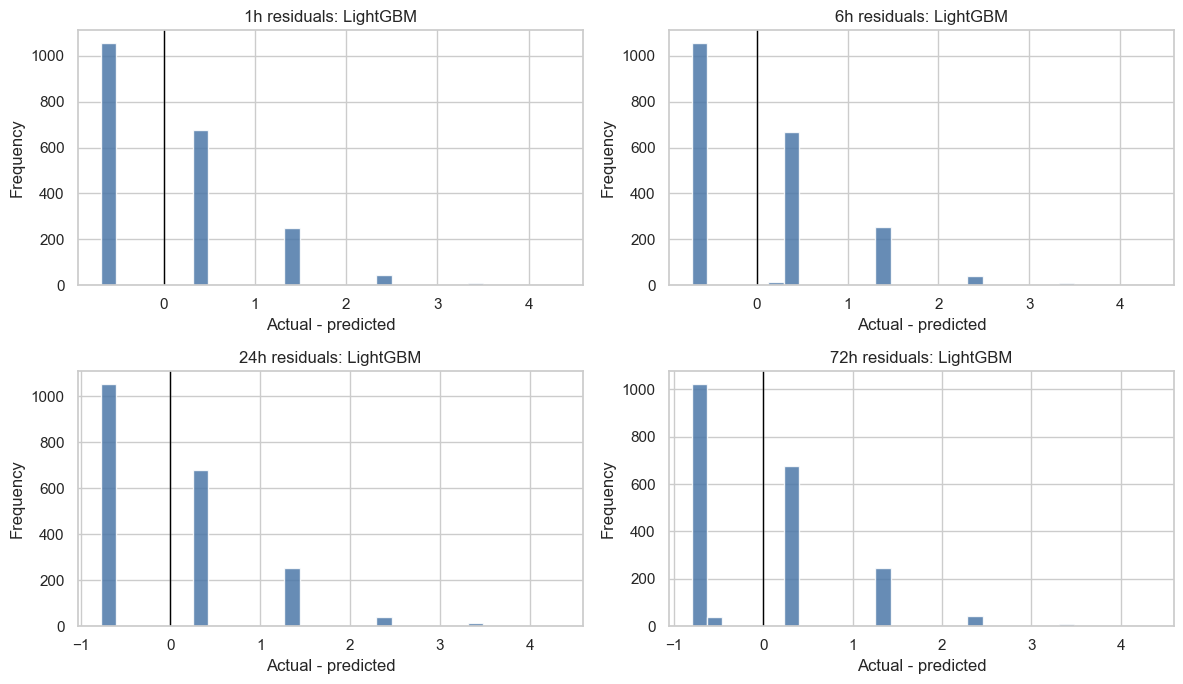

,Horizon,Best Model,Mean Residual,Residual Std,Underprediction Rate,Overprediction Rate
0,1h,LightGBM,0.009022,0.821987,0.483651,0.516349
1,6h,LightGBM,0.008760,0.822845,0.483651,0.516349
2,24h,LightGBM,0.009411,0.822333,0.485115,0.514885
3,72h,LightGBM,0.005820,0.820088,0.481698,0.518302


In [28]:
# Diagnose residual bias for the best model at each horizon.
residual_rows = []
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.ravel()

for axis, (horizon, target_column) in zip(axes, target_horizons.items()):
    horizon_label = f"{horizon}h"
    best_model_name = best_model_by_horizon.loc[best_model_by_horizon["Horizon"] == horizon_label, "Model"].iloc[0]
    predictions = prediction_store[best_model_name].loc[y_test.index, target_column]
    residuals = y_test[target_column] - predictions

    residual_rows.append(
        {
            "Horizon": horizon_label,
            "Best Model": best_model_name,
            "Mean Residual": residuals.mean(),
            "Residual Std": residuals.std(),
            "Underprediction Rate": (residuals > 0).mean(),
            "Overprediction Rate": (residuals < 0).mean(),
        }
    )

    axis.hist(residuals, bins=30, color="#4c78a8", alpha=0.85)
    axis.axvline(0, color="black", linewidth=1)
    axis.set_title(f"{horizon_label} residuals: {best_model_name}")
    axis.set_xlabel("Actual - predicted")
    axis.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

residual_diagnostics_summary = pd.DataFrame(residual_rows)
display(residual_diagnostics_summary)

Residuals centered near zero suggest the model is not consistently over- or under-forecasting. A high underprediction rate is operationally important in emergency care because missed demand can translate into staffing strain and longer waits.

## Business Impact Simulation

This section translates forecast errors into a simple staffing-risk proxy so model performance can be discussed in operational terms.

*Simulate Staffing Impact*

In [29]:
# Estimate theoretical staffing impact from reduced underforecasting.
patients_per_staff_hour = 3
median_wait_minutes = analysis_df["Avg_Waittime"].median(skipna=True)
advanced_model_names = ["LightGBM", "LSTM"]
business_rows = []

for horizon, target_column in target_horizons.items():
    horizon_label = f"{horizon}h"
    baseline_choice = (
        model_metrics[
            (model_metrics["Horizon"] == horizon_label)
            & (model_metrics["Model"].isin(baseline_names))
        ]
        .sort_values("RMSE")
        .iloc[0]
    )
    advanced_choice = (
        model_metrics[
            (model_metrics["Horizon"] == horizon_label)
            & (model_metrics["Model"].isin(advanced_model_names))
        ]
        .sort_values("RMSE")
        .iloc[0]
    )

    actual = y_test[target_column]
    baseline_pred = prediction_store[baseline_choice["Model"]].loc[y_test.index, target_column]
    advanced_pred = prediction_store[advanced_choice["Model"]].loc[y_test.index, target_column]

    def impact_summary(predictions):
        underforecasted_patients = np.maximum(actual - predictions, 0).sum()
        actual_staff = np.ceil(actual / patients_per_staff_hour)
        planned_staff = np.ceil(predictions / patients_per_staff_hour)
        understaffed_staff_hours = np.maximum(actual_staff - planned_staff, 0).sum()
        wait_pressure_proxy_minutes = underforecasted_patients * median_wait_minutes
        return underforecasted_patients, understaffed_staff_hours, wait_pressure_proxy_minutes

    baseline_under, baseline_staff, baseline_pressure = impact_summary(baseline_pred)
    advanced_under, advanced_staff, advanced_pressure = impact_summary(advanced_pred)

    business_rows.append(
        {
            "Horizon": horizon_label,
            "Best Baseline": baseline_choice["Model"],
            "Best Advanced Model": advanced_choice["Model"],
            "Baseline Underforecasted Patients": baseline_under,
            "Advanced Underforecasted Patients": advanced_under,
            "Underforecast Reduction %": ((baseline_under - advanced_under) / baseline_under * 100) if baseline_under else np.nan,
            "Baseline Understaffed Staff-Hours": baseline_staff,
            "Advanced Understaffed Staff-Hours": advanced_staff,
            "Staff-Hour Risk Reduction %": ((baseline_staff - advanced_staff) / baseline_staff * 100) if baseline_staff else np.nan,
            "Baseline Wait-Pressure Proxy Minutes": baseline_pressure,
            "Advanced Wait-Pressure Proxy Minutes": advanced_pressure,
        }
    )

business_impact_summary = pd.DataFrame(business_rows)
display(business_impact_summary)

,Horizon,Best Baseline,Best Advanced Model,Baseline Underforecasted Patients,Advanced Underforecasted Patients,Underforecast Reduction %,Baseline Understaffed Staff-Hours,Advanced Understaffed Staff-Hours,Staff-Hour Risk Reduction %,Baseline Wait-Pressure Proxy Minutes,Advanced Wait-Pressure Proxy Minutes
0,1h,Moving Average 24h,LightGBM,711.791667,716.765383,-0.698760,13.0,13.0,0.0,24912.708333,25086.788403
1,6h,Moving Average 24h,LightGBM,713.041667,717.280822,-0.594517,13.0,13.0,0.0,24956.458333,25104.828765
2,24h,Moving Average 24h,LightGBM,709.500000,717.039423,-1.062639,13.0,13.0,0.0,24832.500000,25096.379819
3,72h,Moving Average 24h,LightGBM,697.000000,713.007373,-2.296610,12.0,12.0,0.0,24395.000000,24955.258060


This simulation is a theoretical decision-support proxy, not a measured clinical outcome. It shows how lower underforecasting could reduce understaffed staff-hours and wait-pressure exposure if staffing decisions were based on the model forecasts.